## Load the Data

In [4]:
from TreeMaker import TreeMaker

data_2006 = TreeMaker.preprocess_census_metadata("C:/Users/aam20/OneDrive - KFUPM/Documents/data/census_ca06_full_metadata.json")
data_2011 = TreeMaker.preprocess_census_metadata("C:/Users/aam20/OneDrive - KFUPM/Documents/data/census_ca11_full_metadata.json")
data_2016 = TreeMaker.preprocess_census_metadata("C:/Users/aam20/OneDrive - KFUPM/Documents/data/census_ca16_full_metadata.json")
data_2021 = TreeMaker.preprocess_census_metadata("C:/Users/aam20/OneDrive - KFUPM/Documents/data/census_ca21_full_metadata.json")

The unique values for the type were:  ['Total' 'Male' 'Female'] and now it is:  ['Total']
The unique values for the type were:  ['Total' 'Male' 'Female'] and now it is:  ['Total']
The unique values for the type were:  ['Total' 'Male' 'Female'] and now it is:  ['Total']
The unique values for the type were:  ['Total' 'Male' 'Female'] and now it is:  ['Total']


In [3]:
data_2016.head()

,vector,description,type,units,parent_vector,aggregation,details
0,v_CA16_401,"Population, 2016",Total,Number,None,Additive,CA 2016 Census; Population and Dwellings; Popu...
1,v_CA16_402,"Population, 2011",Total,Number,None,Additive,CA 2016 Census; Population and Dwellings; Popu...
2,v_CA16_403,"Population percentage change, 2011 to 2016",Total,Number,None,Average of v_CA16_402,CA 2016 Census; Population and Dwellings; Popu...
3,v_CA16_404,Total private dwellings,Total,Number,None,Additive,CA 2016 Census; Population and Dwellings; Tota...
4,v_CA16_405,Private dwellings occupied by usual residents,Total,Number,v_CA16_404,Additive,CA 2016 Census; Population and Dwellings; Tota...


In [3]:
print("The number of vectors in 2006 is:", len(data_2006))
print("The number of vectors in 2011 is:", len(data_2011))
print("The number of vectors in 2016 is:", len(data_2016))
print("The number of vectors in 2021 is:", len(data_2021))


The number of vectors in 2006 is: 1565
The number of vectors in 2011 is: 1429
The number of vectors in 2016 is: 2347
The number of vectors in 2021 is: 2723


-------------------------------

## Jaccard Matching Approach

In [ ]:
jaccard_mapping_21_16 = TreeMaker.match_descriptions_jaccard(data_2021, data_2016, similarity_threshold=0.9)
jaccard_mapping_21_11 = TreeMaker.match_descriptions_jaccard(data_2021, data_2011, similarity_threshold=0.9)
jaccard_mapping_21_06 = TreeMaker.match_descriptions_jaccard(data_2021, data_2006, similarity_threshold=0.9)

### Merge All DataFrames into One DataFrame

In [ ]:
jaccard_merged_df = TreeMaker.merge_mappings(data_2021, jaccard_mapping_21_16, jaccard_mapping_21_11, jaccard_mapping_21_06)
print(f"Base data (2021): {len(data_2021)} rows")
print(f"Merged result: {len(jaccard_merged_df)} rows")

In [ ]:
jaccard_tree = TreeMaker.build_tree(data_2021, jaccard_merged_df, "jaccard_tree","C:/Users/aam20/OneDrive - KFUPM/Abdulmohseen/KAUST - AI/KAUST-Summer/Toronto Work/piccard2/trees")

-------------------

## Multithreaded Approach

In [ ]:
from multithreaded_mapping import match_descriptions_multithreaded

multithreaded_mapping_21_16 = match_descriptions_multithreaded(source_df=data_2021, compare_df=data_2016, similarity_threshold=0.9, max_workers=8)
multithreaded_mapping_21_11 = match_descriptions_multithreaded(source_df=data_2021, compare_df=data_2011, similarity_threshold=0.9, max_workers=8)
multithreaded_mapping_21_06 = match_descriptions_multithreaded(source_df=data_2021, compare_df=data_2006, similarity_threshold=0.9, max_workers=8)

### Merge All DataFrames into One DataFrame

In [ ]:
multithreaded_merged_df = TreeMaker.merge_mappings(data_2021, multithreaded_mapping_21_16, multithreaded_mapping_21_11, multithreaded_mapping_21_06)
print(f"Base data (2021): {len(data_2021)} rows")
print(f"Merged result: {len(multithreaded_merged_df)} rows")

In [ ]:
multithreaded_tree = TreeMaker.build_tree(data_2021, multithreaded_merged_df, "multithreaded_tree","C:/Users/aam20/OneDrive - KFUPM/Abdulmohseen/KAUST - AI/KAUST-Summer/Toronto Work/piccard2/trees")

-----------------------------------------

## Transformer Approach#1

In [2]:
transformer_mapping_21_16 = TreeMaker.match_descriptions_transformer(data_2021, data_2016, similarity_threshold=0.9)
transformer_mapping_21_11 = TreeMaker.match_descriptions_transformer(data_2021, data_2011, similarity_threshold=0.9)
transformer_mapping_21_06 = TreeMaker.match_descriptions_transformer(data_2021, data_2006, similarity_threshold=0.9)

Number of exact matches: 1736


Batches: 100%|██████████| 20/20 [00:06<00:00,  2.88it/s]


Number of exact matches: 1902
Number of exact matches: 892


Batches: 100%|██████████| 17/17 [00:05<00:00,  2.92it/s]


Number of exact matches: 1009
Number of exact matches: 679


Batches: 100%|██████████| 28/28 [00:08<00:00,  3.32it/s]


Number of exact matches: 784


### Merge All DataFrames into One DataFrame

In [ ]:
transformer_merged_df = TreeMaker.merge_mappings(data_2021, transformer_mapping_21_16, transformer_mapping_21_11, transformer_mapping_21_06)
print(f"Base data (2021): {len(data_2021)} rows")
print(f"Merged result: {len(transformer_merged_df)} rows")

In [ ]:
transformer_tree = TreeMaker.build_tree(data_2021, transformer_merged_df, "transformer_tree","C:/Users/aam20/OneDrive - KFUPM/Abdulmohseen/KAUST - AI/KAUST-Summer/Toronto Work/piccard2/trees")

----------------

## Transformer Approach#2 -> using details

In [ ]:
transformer_advanced_mapping_21_16 = TreeMaker.match_descriptions_details_sentence_transformer(data_2021, data_2016, similarity_threshold=0.9)
transformer_advanced_mapping_21_11 = TreeMaker.match_descriptions_details_sentence_transformer(data_2021, data_2011, similarity_threshold=0.9)
transformer_advanced_mapping_21_06 = TreeMaker.match_descriptions_details_sentence_transformer(data_2021, data_2006, similarity_threshold=0.9)

### Merge All DataFrames into One DataFrame

In [ ]:
transformer_advanced_merged_df = TreeMaker.merge_mappings(data_2021, transformer_advanced_mapping_21_16, transformer_advanced_mapping_21_11, transformer_advanced_mapping_21_06)
print(f"Base data (2021): {len(data_2021)} rows")
print(f"Merged result: {len(transformer_advanced_merged_df)} rows")

In [ ]:
transformer_advanced_tree = TreeMaker.build_tree(data_2021, transformer_advanced_merged_df, "transformer_advanced_tree","C:/Users/aam20/OneDrive - KFUPM/Abdulmohseen/KAUST - AI/KAUST-Summer/Toronto Work/piccard2/trees")

# Evaluation

In [5]:
import re

def parse_tree_to_dict(filepath):
    tree_dict = {}
    node_pattern = re.compile(
        r'(\w+)\s+\[label="([^"]+)"\s+fillcolor=([^\]]+)\]'
    )

    with open(filepath, encoding='utf-8') as f:
        for line in f:
            match = node_pattern.match(line.strip())
            if match:
                node_id, label, fillcolor = match.groups()
                # Split the label into lines
                label_lines = label.split('\\n')
                description = label_lines[0]
                year_map = {}
                for entry in label_lines[1:]:
                    # Match lines like "2021: v_CA21_4728"
                    if ':' in entry:
                        year, val = entry.split(':', 1)
                        year_map[year.strip()] = val.strip()
                # Store in dictionary
                tree_dict[node_id] = {
                    "description": description,
                    **year_map,
                    "fillcolor": fillcolor
                }
    return tree_dict


In [6]:
# Usage
dict_jaccard = parse_tree_to_dict('trees/jaccard_tree')
dict_transformer = parse_tree_to_dict('trees/transformer_tree')
dict_advanced_transformer = parse_tree_to_dict('trees/transformer_advanced_tree')

print("Number of vectors in Jaccard tree: ", len(dict_jaccard))
print("Number of vectors in Transformer tree: ", len(dict_transformer))
print("Number of vectors in Advanced Transformer tree: ", len(dict_advanced_transformer))



Number of vectors in Jaccard tree:  1888
Number of vectors in Transformer tree:  1990
Number of vectors in Advanced Transformer tree:  1990


In [7]:
def get_vector_by_description(description, data_df):
    if description == "Not available":
        return "Not available"
    # Try exact match
    match = data_df[data_df['description'] == description]
    if not match.empty:
        return match.iloc[0]['vector']
    # Try substring match
    match = data_df[data_df['description'].str.contains(description, na=False)]
    if not match.empty:
        return match.iloc[0]['vector']
    return None

def get_clean_text(cell):
    for sup in cell.find_all('sup'):
        sup.decompose()
    for span in cell.find_all('span'):
        span.decompose()
    for a in cell.find_all('a'):
        a.decompose()
    # Use separator=" " to ensure spaces between text nodes
    return cell.get_text(separator=" ", strip=True)

In [ ]:
from bs4 import BeautifulSoup

# Read the file
with open('trees/rawDataLanguage.txt', encoding='utf-8') as f:
    html = f.read()

soup = BeautifulSoup(html, 'html.parser')

# Initialize the dictionary
lang_dict = {}

# Loop through each row
print("Number of vectors in language row data: ", len(soup.find_all('tr', class_='highlight-row')))
for row in soup.find_all('tr', class_='highlight-row'):
    cells = row.find_all(['th', 'td'])
    if len(cells) == 3:
        key_2021 = get_clean_text(cells[0])
        val_2016 = get_clean_text(cells[1])
        val_2011 = get_clean_text(cells[2])


        # Get vector names instead of descriptions
        vector_2016 = get_vector_by_description(val_2016, data_2016)
        vector_2011 = get_vector_by_description(val_2011, data_2011)
        vector_2021 = get_vector_by_description(key_2021, data_2021)
        if vector_2021 is not None:
            lang_dict[vector_2021] = {
                '2016': vector_2016,
                '2011': vector_2011
            }

print("Number of valid vectors in language row data: ", len(lang_dict))

Number of vectors in language row data:  537


C:\Users\aam20\AppData\Local\Temp\ipykernel_20988\1957939440.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  match = data_df[data_df['description'].str.contains(description, na=False)]


Number of valid vectors in language row data:  322


In [20]:
import pandas as pd
def evaluate_tree(tree_dict, gt_dict):
    correct_2016 = 0
    miss_2016 = 0
    correct_2011 = 0
    miss_2011 = 0
    for vector_2021, gt in gt_dict.items():

        pred = tree_dict.get(vector_2021, {})
        # 2016
        gt_2016 = gt.get('2016')
        pred_2016 = pred.get('2016')
        if gt_2016 not in [None, "Not available"]:
            if pred_2016 == gt_2016:
                correct_2016 += 1
            else:
                miss_2016 += 1
        else:
            if pred_2016 is not None:
                miss_2016 += 1
            else:
                correct_2016 += 1
        # 2011
        gt_2011 = gt.get('2011')
        pred_2011 = pred.get('2011')
        if gt_2011 not in [None, "Not available"]:
            if pred_2011 == gt_2011:
                correct_2011 += 1
            else:
                miss_2011 += 1
        else:
            if pred_2011 is not None:
                miss_2011 += 1
            else:
                correct_2011 += 1
    return pd.DataFrame({
        "2016": [correct_2016, miss_2016],
        "2011": [correct_2011, miss_2011]
    },index=["Correct", "Miss"])

In [21]:
results_jaccard = evaluate_tree(dict_jaccard, lang_dict)
results_transformer = evaluate_tree(dict_transformer, lang_dict)
results_advanced_transformer = evaluate_tree(dict_advanced_transformer, lang_dict)

print("The result of Jaccard is")

The result of Jaccard is


In [27]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(4, 3))
# sns.heatmap(results_jaccard.T, annot=True, fmt="d", cmap="Blues")
# plt.title("Confusion Matrix - Jaccard")
# plt.xlabel("Prediction")
# plt.ylabel("Year")
# plt.show()

# plt.figure(figsize=(4, 3))
# sns.heatmap(results_transformer.T, annot=True, fmt="d", cmap="Blues")
# plt.title("Confusion Matrix - Transformer")
# plt.xlabel("Prediction")
# plt.ylabel("Year")
# plt.show()


# plt.figure(figsize=(4, 3))
# sns.heatmap(results_advanced_transformer.T, annot=True, fmt="d", cmap="Blues")
# plt.title("Confusion Matrix - Advanced Transformer")
# plt.xlabel("Prediction")
# plt.ylabel("Year")
# plt.show()

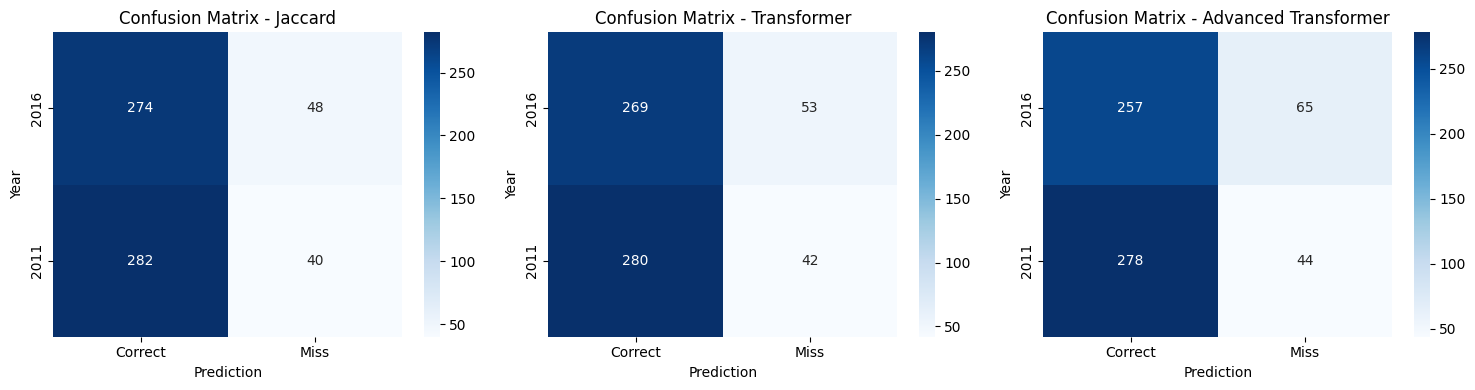

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with 1 row and 3 columns of subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot Jaccard confusion matrix
sns.heatmap(results_jaccard.T, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix - Jaccard")
axes[0].set_xlabel("Prediction")
axes[0].set_ylabel("Year")

# Plot Transformer confusion matrix
sns.heatmap(results_transformer.T, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix - Transformer")
axes[1].set_xlabel("Prediction")
axes[1].set_ylabel("Year")

# Plot Advanced Transformer confusion matrix
sns.heatmap(results_advanced_transformer.T, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Confusion Matrix - Advanced Transformer")
axes[2].set_xlabel("Prediction")
axes[2].set_ylabel("Year")

plt.tight_layout()
plt.show()